# 📰 Weak Supervision for Clickbait Detection with Snorkel
### Part 1 of 3: Data Labeling

In this lab we use **Snorkel** to build a training set for a **clickbait headline detector** *without hand-labeling a single training example*.

Instead of labeling ~29,000 headlines by hand, we write small heuristic **labeling functions (LFs)**

## The dataset

The [Stop Clickbait corpus](https://github.com/bhargaviparanjape/clickbait) contains 16,000 clickbait headlines (BuzzFeed, Upworthy, ViralNova, Scoopwhoop, ...) and 16,000 non-clickbait headlines (New York Times, The Guardian, The Hindu, WikiNews).

`utils.load_clickbait_dataset()`:

* **train** – 29,000 headlines, **labels hidden** (we pretend they are unlabeled)
* **dev** – 200 labeled headlines sampled from train, used *only* to develop and sanity-check LFs
* **valid** – 1,000 labeled headlines (used in Part 3)
* **test** – 2,000 labeled headlines, held out for final evaluation

In [1]:
%matplotlib inline

import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["PYTHONHASHSEED"] = "0"
np.random.seed(123)

pd.set_option("display.max_colwidth", 90)

In [2]:
from utils import load_clickbait_dataset

df_train, df_dev, df_valid, df_test = load_clickbait_dataset(split_dev_valid=True)

Y_dev = df_dev.label.values
Y_test = df_test.label.values

print(f"train: {len(df_train):,} (unlabeled)  dev: {len(df_dev)}  valid: {len(df_valid):,}  test: {len(df_test):,}")
print("train labels:", df_train.label.unique(), "-> hidden")

train: 29,000 (unlabeled)  dev: 200  valid: 1,000  test: 2,000
train labels: [-1] -> hidden


In [3]:
ABSTAIN = -1
NEWS = 0
CLICKBAIT = 1

Let's look at a few labeled dev headlines to build intuition.

In [4]:
df_dev.sample(12, random_state=7)

,text,label
4203,This Video Perfectly Captures The Sriracha Lover's Struggle,1
23963,Are You Team Marvel Or Team Capcom,1
21506,Every Piece Of Evidence That Proves Anna Faris And Chris Pratt Have The Cutest Family ...,1
23469,"This Is What ""Mean Girls"" Would Be Like If It Were Set In 2015",1
31794,Wild Ways People Use The Placenta,1
4746,"Baby in California born with 12 functioning fingers and toes, in a rare case of polyda...",0
14117,19 Of The Most Influential Canadians As Youngsters,1
26030,Toxic Dose of Selenium Cited in Deaths of Polo Horses,0
21726,43 Tweets About Dogs That Will Make You Laugh Every Single Time,1
24386,Iraqi rebels seize control of Ramadi's inner city,0


## 1. Writing our first labeling function

A labeling function takes a single data point (a row of the DataFrame) and returns `CLICKBAIT`, `NEWS`, or `ABSTAIN`. We start with the classic signal.

In [ ]:
from snorkel.labeling import labeling_function


@labeling_function()
def starts_with_number(x):
    """Listicles: '17 Things Only 90s Kids Understand'."""
    return CLICKBAIT if re.match(r"^\d+\s", x.text) else ABSTAIN

In [ ]:
from snorkel.labeling import PandasLFApplier, LFAnalysis

applier = PandasLFApplier(lfs=[starts_with_number])
L_dev = applier.apply(df=df_dev)

LFAnalysis(L=L_dev, lfs=[starts_with_number]).lf_summary(Y=Y_dev)


  0%|          | 0/200 [00:00<?, ?it/s]


100%|██████████| 200/200 [00:00<00:00, 61576.80it/s]

,j,Polarity,Coverage,Overlaps,Conflicts,Correct,Incorrect,Emp. Acc.
starts_with_number,0,[1],0.14,0.0,0.0,26,2,0.928571


In [ ]:
from snorkel.analysis import get_label_buckets

buckets = get_label_buckets(Y_dev, L_dev[:, 0])
df_dev.iloc[buckets.get((NEWS, CLICKBAIT), [])]

,text,label
13117,2007 FIFA U-17 World Cup: Ghana beat Peru in Quarter finals,0
2609,80 Are Killed in 3 Suicide Bombings in Iraq,0


Its mistakes are news headlines that *report a count* ("3 killed in ..."). That's fine: an LF doesn't need to be perfect, since the `LabelModel` will estimate its accuracy. We'll add LFs that vote NEWS on hard-news vocabulary to counterbalance it.

## 2. Keyword LFs with a `LabelingFunction` factory

Many signals are just keyword lists. Instead of writing one decorated function per list, we build them with `LabelingFunction` and a shared `keyword_lookup`. We match on **whole words** (not substrings) so that "you" doesn't fire on "young".

In [8]:
from snorkel.labeling import LabelingFunction


def keyword_lookup(x, keywords, label):
    text = " " + re.sub(r"[^\w' ]", " ", x.text.lower()) + " "
    return label if any(f" {kw} " in text for kw in keywords) else ABSTAIN


def make_keyword_lf(name, keywords, label):
    return LabelingFunction(
        name=f"kw_{name}",
        f=keyword_lookup,
        resources=dict(keywords=keywords, label=label),
    )


"""Clickbait talks directly to the reader."""
kw_you = make_keyword_lf("you", ["you", "your", "you're", "you'll", "yourself"], CLICKBAIT)

"""Clickbait points at something without naming it: 'This Dog Will Melt Your Heart'."""
kw_this = make_keyword_lf("this", ["this", "these", "here's", "here are", "this is"], CLICKBAIT)

"""Hyperbole and superlatives."""
kw_superlative = make_keyword_lf(
    "superlative",
    ["best", "worst", "most", "ever", "literally", "actually", "perfect", "totally", "absolutely"],
    CLICKBAIT,
)

"""Internet-speak / emotional reaction words."""
kw_emotion = make_keyword_lf(
    "emotion",
    ["omg", "lol", "wtf", "cute", "hilarious", "amazing", "adorable", "awesome", "insane", "weird"],
    CLICKBAIT,
)

"""Hard-news verbs and institutions."""
kw_news = make_keyword_lf(
    "news",
    ["says", "kills", "killed", "dies", "dead", "wins", "announces", "plans", "agrees", "rejects",
     "urges", "warns", "charged", "report", "officials", "police", "court", "minister",
     "government", "president", "election", "u.s.", "billion", "million"],
    NEWS,
)

## 3. Regex and pattern-based LFs

In [9]:
@labeling_function()
def regex_curiosity_gap(x):
    """Withholds information to force a click: 'You Won't Believe What Happened Next'."""
    pattern = (
        r"(won'?t believe|what happen|will make you|need to know|can you|which .* are you"
        r"|guess|reasons why|things (that|you|only|every))"
    )
    return CLICKBAIT if re.search(pattern, x.text, flags=re.I) else ABSTAIN


@labeling_function()
def question_word_start(x):
    """Quiz-style headlines: 'How Well Do You Remember Friends' (usually no '?')."""
    starts = re.match(
        r"^(how|why|what|which|who|can|do|does|is|are|should|would|have)\b", x.text, flags=re.I
    )
    return CLICKBAIT if starts and "?" not in x.text else ABSTAIN


@labeling_function()
def has_colon_or_semicolon(x):
    """News desks use 'Topic: detail' and ';' constructions."""
    return NEWS if re.search(r"[:;]", x.text) else ABSTAIN

### A style heuristic, and a word of caution

Clickbait sites write in **Title Case** ("What Happens When You Mix..."), while several news outlets in this corpus (The Guardian, The Hindu, WikiNews) use **sentence case**, where small function words stay lowercase.

In [10]:
FUNCTION_WORDS = {"in", "of", "the", "to", "for", "on", "at", "a", "and"}


@labeling_function()
def lowercase_function_words(x):
    """Sentence-case headline style ('Bus crash in the Alps kills 12')."""
    tokens = x.text.split()[1:]  # skip the first word, which is always capitalised
    return NEWS if any(t in FUNCTION_WORDS for t in tokens) else ABSTAIN

⚠️ This LF will turn out to be extremely accurate on this corpus. Note, though, that it picks up a **formatting convention of the source outlets**, not something about clickbait itself. A model that relies on it could break as soon as headlines arrive lower-cased, or from an outlet with a different style guide (e.g. the NYT uses Title Case). That's a good example of **dataset artifacts / shortcut learning**, and it's the kind of thing we'll check with slicing in Part 3.

## 4. LFs that use preprocessors and third-party models

### spaCy named entities

News is about **places, organisations and nationalities**. `nlp_labeling_function` runs spaCy once per headline (memoized) and exposes the parsed `Doc` as `x.doc`.

In [11]:
from snorkel.labeling.lf.nlp import nlp_labeling_function


@nlp_labeling_function()
def has_place_or_org(x):
    """Mentions a country/city (GPE), organisation (ORG) or nationality (NORP)."""
    return NEWS if any(ent.label_ in ("GPE", "ORG", "NORP") for ent in x.doc.ents) else ABSTAIN

### TextBlob subjectivity

TextBlob's pretrained sentiment analyzer was not built for clickbait, but clickbait is opinionated and emotional, so **high subjectivity** is a reasonable weak signal.

In [12]:
from snorkel.preprocess import preprocessor
from textblob import TextBlob


@preprocessor(memoize=True)
def textblob_sentiment(x):
    scores = TextBlob(x.text)
    x.polarity = scores.sentiment.polarity
    x.subjectivity = scores.sentiment.subjectivity
    return x


@labeling_function(pre=[textblob_sentiment])
def textblob_subjective(x):
    return CLICKBAIT if x.subjectivity >= 0.6 else ABSTAIN

### An LF that didn't make the cut

The opposite intuition, "long, perfectly neutral headlines are news", sounds plausible. Let's check it on the dev set before trusting it.

In [13]:
@labeling_function(pre=[textblob_sentiment])
def textblob_neutral_long(x):
    return NEWS if x.subjectivity == 0 and len(x.text.split()) >= 8 else ABSTAIN


L_dev_candidate = PandasLFApplier([textblob_subjective, textblob_neutral_long]).apply(df_dev)
LFAnalysis(L_dev_candidate, [textblob_subjective, textblob_neutral_long]).lf_summary(Y=Y_dev)


  0%|          | 0/200 [00:00<?, ?it/s]


100%|██████████| 200/200 [00:00<00:00, 6462.02it/s]

,j,Polarity,Coverage,Overlaps,Conflicts,Correct,Incorrect,Emp. Acc.
textblob_subjective,0,[1],0.18,0.0,0.0,27,9,0.750
textblob_neutral_long,1,[0],0.32,0.0,0.0,40,24,0.625


`textblob_neutral_long` is only about 62% accurate on dev, well below every other LF (and about 54% if you check it on the full train labels). Plenty of listicles are long and contain no "opinion" words. It would mostly add noise, so **we drop it**. Checking each LF against a small labeled dev set like this is the core of the Snorkel development loop.

## 5. Applying all LFs

Our final set has **12 labeling functions** (8 vote CLICKBAIT, 4 vote NEWS).

In [14]:
lfs = [
    starts_with_number,
    kw_you,
    kw_this,
    kw_superlative,
    kw_emotion,
    kw_news,
    regex_curiosity_gap,
    question_word_start,
    has_colon_or_semicolon,
    lowercase_function_words,
    has_place_or_org,
    textblob_subjective,
]

applier = PandasLFApplier(lfs=lfs)
L_train = applier.apply(df=df_train)
L_dev = applier.apply(df=df_dev)
L_test = applier.apply(df=df_test)


  0%|          | 0/29000 [00:00<?, ?it/s]


  0%|          | 37/29000 [00:00<01:18, 367.66it/s]


  0%|          | 76/29000 [00:00<01:16, 378.38it/s]


  0%|          | 115/29000 [00:00<01:15, 382.81it/s]


  1%|          | 155/29000 [00:00<01:14, 386.33it/s]

...


 94%|█████████▍| 1879/2000 [00:04<00:00, 373.10it/s]


 96%|█████████▌| 1918/2000 [00:04<00:00, 376.18it/s]


 98%|█████████▊| 1960/2000 [00:05<00:00, 386.26it/s]


100%|██████████| 2000/2000 [00:05<00:00, 390.24it/s]


100%|██████████| 2000/2000 [00:05<00:00, 386.81it/s]

**On the unlabeled train set** we can still measure coverage, overlaps and conflicts:

In [15]:
LFAnalysis(L=L_train, lfs=lfs).lf_summary()

,j,Polarity,Coverage,Overlaps,Conflicts
starts_with_number,0,[1],0.195034,0.152586,0.046966
kw_you,1,[1],0.206276,0.190655,0.029724
kw_this,2,[1],0.092172,0.072310,0.017207
kw_superlative,3,[1],0.070483,0.063483,0.015345
kw_emotion,4,[1],0.024862,0.024690,0.006897
kw_news,5,[0],0.117207,0.110828,0.011276
regex_curiosity_gap,6,[1],0.061862,0.061448,0.007966
question_word_start,7,[1],0.097897,0.092276,0.010862
has_colon_or_semicolon,8,[0],0.039483,0.035690,0.012207
lowercase_function_words,9,[0],0.365897,0.299862,0.037621


**On the labeled dev set** we also get the empirical accuracy of every LF:

In [16]:
LFAnalysis(L=L_dev, lfs=lfs).lf_summary(Y=Y_dev)

,j,Polarity,Coverage,Overlaps,Conflicts,Correct,Incorrect,Emp. Acc.
starts_with_number,0,[1],0.140,0.115,0.035,26,2,0.928571
kw_you,1,[1],0.200,0.185,0.045,40,0,1.000000
kw_this,2,[1],0.115,0.090,0.010,23,0,1.000000
kw_superlative,3,[1],0.050,0.050,0.020,10,0,1.000000
kw_emotion,4,[1],0.025,0.025,0.010,5,0,1.000000
kw_news,5,[0],0.140,0.125,0.015,28,0,1.000000
regex_curiosity_gap,6,[1],0.100,0.100,0.015,20,0,1.000000
question_word_start,7,[1],0.115,0.100,0.015,22,1,0.956522
has_colon_or_semicolon,8,[0],0.030,0.025,0.015,5,1,0.833333
lowercase_function_words,9,[0],0.365,0.285,0.030,73,0,1.000000


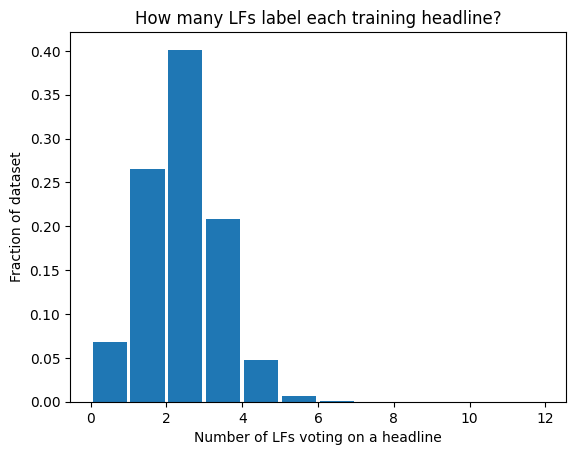

Headlines with at least one LF vote: 93.1%


In [17]:
def plot_label_frequency(L):
    plt.hist((L != ABSTAIN).sum(axis=1), density=True, bins=range(L.shape[1] + 1), rwidth=0.9)
    plt.xlabel("Number of LFs voting on a headline")
    plt.ylabel("Fraction of dataset")
    plt.title("How many LFs label each training headline?")
    plt.show()


plot_label_frequency(L_train)
print(f"Headlines with at least one LF vote: {(L_train != ABSTAIN).any(axis=1).mean() * 100:.1f}%")

## 6. Combining LF outputs with the Label Model

**Baseline: majority vote.** Every LF counts equally.

In [18]:
from snorkel.labeling.model import MajorityLabelVoter

majority_model = MajorityLabelVoter()
preds_train = majority_model.predict(L=L_train)

**The LabelModel** learns each LF's accuracy from the agreements and disagreements in `L_train`, using no labels at all, and weights the LFs accordingly.

In [19]:
from snorkel.labeling.model import LabelModel

label_model = LabelModel(cardinality=2, verbose=True)
label_model.fit(L_train=L_train, n_epochs=500, log_freq=100, seed=123)

INFO:root:Computing O...


INFO:root:Estimating \mu...



  0%|          | 0/500 [00:00<?, ?epoch/s]

INFO:root:[0 epochs]: TRAIN:[loss=0.273]


INFO:root:[100 epochs]: TRAIN:[loss=0.010]


INFO:root:[200 epochs]: TRAIN:[loss=0.010]


INFO:root:[300 epochs]: TRAIN:[loss=0.010]


INFO:root:[400 epochs]: TRAIN:[loss=0.010]



100%|██████████| 500/500 [00:00<00:00, 8041.44epoch/s]


INFO:root:Finished Training


In [20]:
majority_acc = majority_model.score(L=L_test, Y=Y_test, tie_break_policy="random")["accuracy"]
label_model_acc = label_model.score(L=L_test, Y=Y_test, tie_break_policy="random")["accuracy"]

print(f"{'Majority Vote Accuracy:':<25} {majority_acc * 100:.1f}%")
print(f"{'Label Model Accuracy:':<25} {label_model_acc * 100:.1f}%")

Majority Vote Accuracy:   91.6%
Label Model Accuracy:     93.7%


### What did the LabelModel learn about our LFs?

`get_weights()` returns the LabelModel's estimated accuracy for each LF. We compare it with the empirical accuracy on the dev set. Remember that the LabelModel never saw a label.

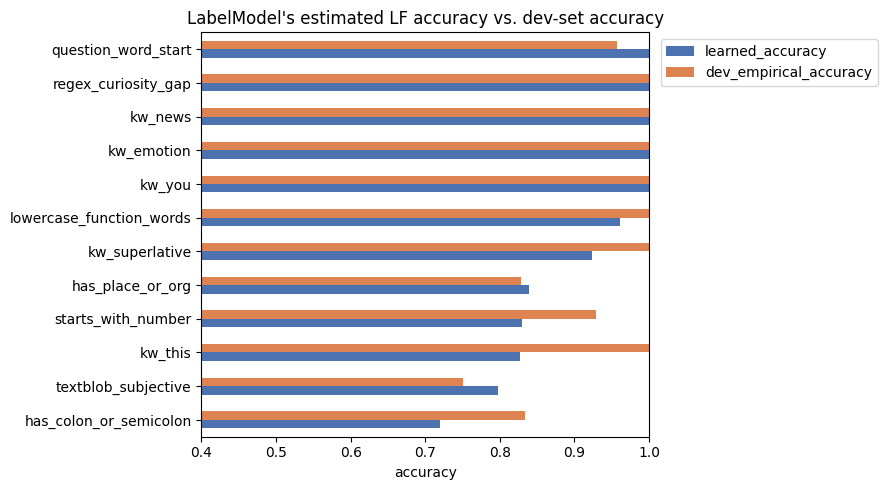

,learned_accuracy,dev_empirical_accuracy
has_colon_or_semicolon,0.720,0.833
textblob_subjective,0.798,0.750
kw_this,0.827,1.000
starts_with_number,0.830,0.929
has_place_or_org,0.838,0.828
kw_superlative,0.924,1.000
lowercase_function_words,0.961,1.000
kw_you,1.000,1.000
kw_emotion,1.000,1.000
kw_news,1.000,1.000


In [21]:
dev_summary = LFAnalysis(L=L_dev, lfs=lfs).lf_summary(Y=Y_dev)
weights = pd.DataFrame(
    {
        "learned_accuracy": label_model.get_weights(),
        "dev_empirical_accuracy": dev_summary["Emp. Acc."].values,
    },
    index=[lf.name for lf in lfs],
).sort_values("learned_accuracy")

ax = weights.plot.barh(figsize=(9, 5), color=["#4C72B0", "#DD8452"])
ax.set_xlim(0.4, 1.0)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
ax.set_xlabel("accuracy")
ax.set_title("LabelModel's estimated LF accuracy vs. dev-set accuracy")
plt.tight_layout()
plt.show()
weights.round(3)

### Probabilistic labels

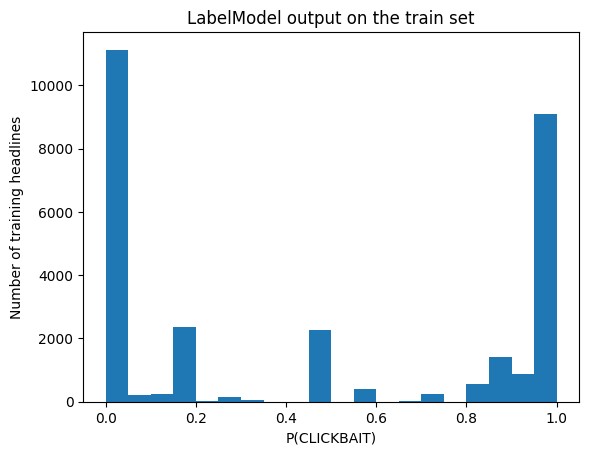

In [22]:
def plot_probabilities_histogram(Y):
    plt.hist(Y, bins=20)
    plt.xlabel("P(CLICKBAIT)")
    plt.ylabel("Number of training headlines")
    plt.title("LabelModel output on the train set")
    plt.show()


probs_train = label_model.predict_proba(L=L_train)
plot_probabilities_histogram(probs_train[:, CLICKBAIT])

### Filtering out unlabeled data points

Headlines where every LF abstained carry no signal, so we drop them before training.

In [23]:
from snorkel.labeling import filter_unlabeled_dataframe
from snorkel.utils import probs_to_preds

df_train_filtered, probs_train_filtered = filter_unlabeled_dataframe(
    X=df_train, y=probs_train, L=L_train
)
print(f"Kept {len(df_train_filtered):,} of {len(df_train):,} training headlines")

Kept 27,009 of 29,000 training headlines


### Saving the weak labels as a pipeline artifact

Part 3 analyses the model trained on these labels, so we save them to disk instead of recomputing all LFs there. In a real pipeline this file would be versioned (e.g. with DVC) alongside the LF code that produced it.

In [24]:
weak_labels = pd.DataFrame(
    {
        "text": df_train_filtered.text.values,
        "weak_label": probs_to_preds(probs_train_filtered),
        "p_clickbait": probs_train_filtered[:, CLICKBAIT].round(4),
    }
)
weak_labels.to_csv("data/clickbait/weak_labels_train.csv", index=False)
print(f"Saved {len(weak_labels):,} weak labels -> data/clickbait/weak_labels_train.csv")
weak_labels.head()

Saved 27,009 weak labels -> data/clickbait/weak_labels_train.csv


,text,weak_label,p_clickbait
0,Kahne Gives Petty Team First Win in 10 Years,0,0.006
1,Grover Norquist attempts to trademark 'K Street Project',0,0.006
2,17 Boozy Ice Cream Treats You Can Actually Make This Holiday Season,1,1.000
3,Jailed American journalist in Iran sentenced to eight years in prison,0,0.006
4,This Color Test Will Determine Your Dominant Personality Trait,1,1.000


## 7. Training a classifier

The LabelModel can only label headlines that some LF fires on, and it needs the LFs at prediction time. We now train a **discriminative end model** on its labels, which can generalize to any headline using the full text.

**Features:** TF-IDF over unigrams and bigrams (`sublinear_tf` dampens repeated words).
**Model:** a linear SVM, which is fast and strong on sparse text features.

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)
X_train = vectorizer.fit_transform(df_train_filtered.text.tolist())
X_test = vectorizer.transform(df_test.text.tolist())

preds_train_filtered = probs_to_preds(probs=probs_train_filtered)
print("TF-IDF feature matrix:", X_train.shape)

TF-IDF feature matrix: (27009, 33910)


In [26]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(C=0.1)
svm_model.fit(X=X_train, y=preds_train_filtered)

svm_acc = svm_model.score(X=X_test, y=Y_test)
print(f"Test Accuracy (TF-IDF + LinearSVC on weak labels): {svm_acc * 100:.1f}%")

Test Accuracy (TF-IDF + LinearSVC on weak labels): 94.2%


### How good is that? Two reference points

1. **The reference lab's setup** (CountVectorizer 1–5 grams + LogisticRegression) on the same weak labels.
2. **A supervised upper bound:** the same TF-IDF + SVM trained on the *true* labels of all 29,000 training headlines, i.e. what we would get if we had paid someone to hand-label everything.

In [27]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression

# 1. reference-lab pipeline on weak labels
count_vec = CountVectorizer(ngram_range=(1, 5))
lr_model = LogisticRegression(C=1e3, solver="liblinear")
lr_model.fit(count_vec.fit_transform(df_train_filtered.text), preds_train_filtered)
lr_acc = lr_model.score(count_vec.transform(df_test.text), Y_test)

# 2. supervised upper bound (uses gold train labels; for comparison only)
df_train_gold, _ = load_clickbait_dataset(load_train_labels=True)
gold_vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)
gold_svm = LinearSVC(C=0.1).fit(gold_vec.fit_transform(df_train_gold.text), df_train_gold.label)
gold_acc = gold_svm.score(gold_vec.transform(df_test.text), Y_test)

results = pd.DataFrame(
    {
        "approach": [
            "Majority vote over LFs",
            "Snorkel LabelModel",
            "CountVec + LogReg (reference lab) on weak labels",
            "TF-IDF + LinearSVC on weak labels (ours)",
            "TF-IDF + LinearSVC on GOLD labels (upper bound)",
        ],
        "test_accuracy_%": [majority_acc, label_model_acc, lr_acc, svm_acc, gold_acc],
    }
)
results["test_accuracy_%"] = (results["test_accuracy_%"] * 100).round(1)
results

,approach,test_accuracy_%
0,Majority vote over LFs,91.6
1,Snorkel LabelModel,93.7
2,CountVec + LogReg (reference lab) on weak labels,93.4
3,TF-IDF + LinearSVC on weak labels (ours),94.2
4,TF-IDF + LinearSVC on GOLD labels (upper bound),97.5


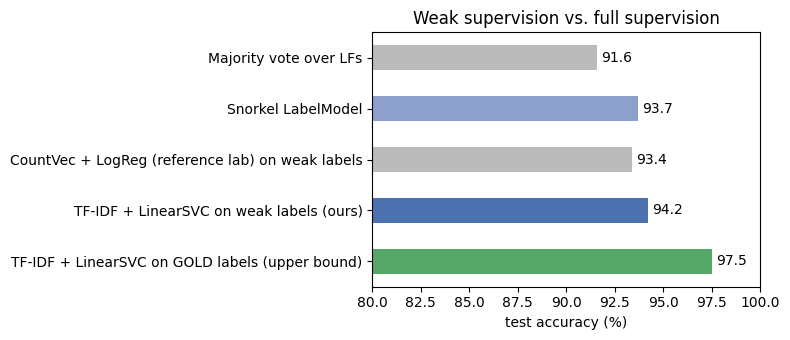

In [28]:
ax = results.set_index("approach")["test_accuracy_%"].plot.barh(
    figsize=(8, 3.5), color=["#bbbbbb", "#8da0cb", "#bbbbbb", "#4C72B0", "#55A868"]
)
ax.set_xlim(80, 100)
ax.set_xlabel("test accuracy (%)")
ax.set_ylabel("")
ax.invert_yaxis()
for i, v in enumerate(results["test_accuracy_%"]):
    ax.text(v + 0.2, i, f"{v:.1f}", va="center")
plt.title("Weak supervision vs. full supervision")
plt.tight_layout()
plt.show()

Let's sanity-check the end model on some brand-new headlines:

In [29]:
new_headlines = [
    "Central bank raises interest rates for third time this year",
    "This Cat Tried To Catch A Laser And The Ending Will Make You Cry",
    "17 Struggles Only People Who Hate Mornings Will Understand",
    "Floods displace thousands in northern India",
    "Which Hogwarts House Do You Actually Belong In",
]
for h, p in zip(new_headlines, svm_model.predict(vectorizer.transform(new_headlines))):
    print(f"{'CLICKBAIT' if p == CLICKBAIT else 'NEWS':>9} | {h}")

     NEWS | Central bank raises interest rates for third time this year
CLICKBAIT | This Cat Tried To Catch A Laser And The Ending Will Make You Cry
CLICKBAIT | 17 Struggles Only People Who Hate Mornings Will Understand
     NEWS | Floods displace thousands in northern India
CLICKBAIT | Which Hogwarts House Do You Actually Belong In
